1.1 Подготовить данные для анализа.

In [ ]:
import pandas as pd

# 1.1 Preparing data for analysis
# Load the dataset into a pandas DataFrame
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

# Drop rows with missing values in 'bmi' or 'age' to ensure clean analysis
df = df.dropna(subset=["bmi", "age"])

# Verify that the 'id' column is unique and not needed for regression [cite: 7]
df = df.drop(columns=["id"])

display(df)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5104,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


1.2. Сделать визуализацию данных.

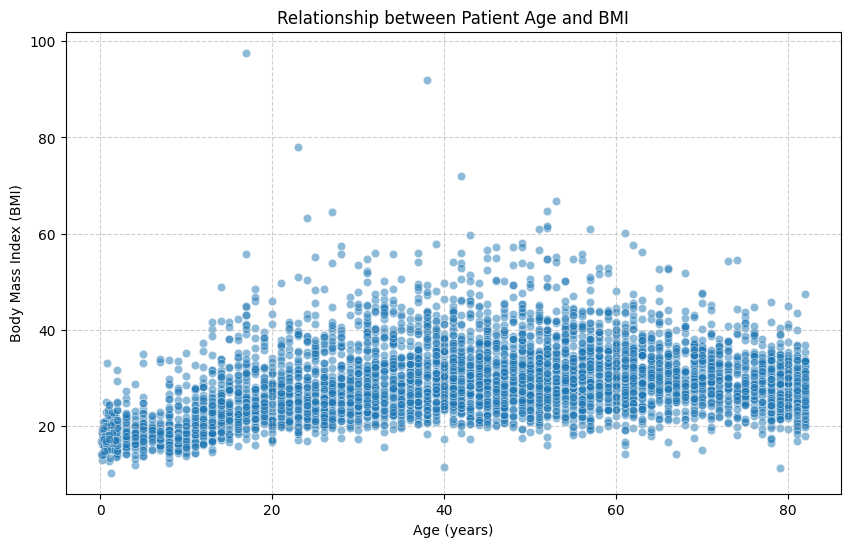

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1.2. Data visualization
plt.figure(figsize=(10, 6))

# Creating a scatter plot to see the relationship between Age and BMI
sns.scatterplot(data=df, x="age", y="bmi", alpha=0.5)

# Adding titles and labels for clarity
plt.title("Relationship between Patient Age and BMI")
plt.xlabel("Age (years)")
plt.ylabel("Body Mass Index (BMI)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

1.3. Найти описательные статистики исходных данных. Сделать предварительные выводы о
свойствах исходных данных.

,age,bmi
count,4909.000000,4909.000000
mean,42.865374,28.893237
std,22.555115,7.854067
min,0.080000,10.300000
25%,25.000000,23.500000
50%,44.000000,28.100000
75%,60.000000,33.100000
max,82.000000,97.600000



Skewness:
age   -0.11907
bmi    1.05534
dtype: float64


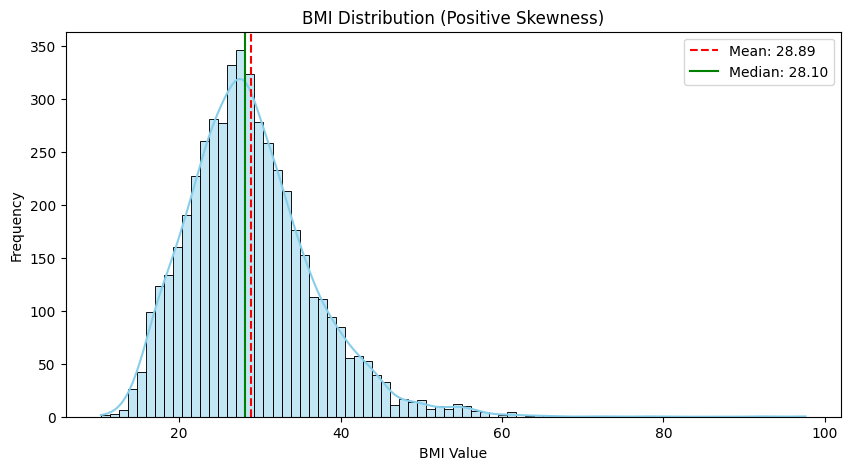

In [9]:
# 1.3. Calculating descriptive statistics
# Focus on the variables of interest: age and bmi
stats = df[["age", "bmi"]].describe()

# Adding median (50th percentile is already there, but we can be explicit)
# and skewness/kurtosis for deeper analysis
display(stats)

# Additional stats for distribution analysis
print(f"\nSkewness:\n{df[['age', 'bmi']].skew()}")

# 1.4. Visualizing skewness with a histogram
plt.figure(figsize=(10, 5))

# Plotting BMI distribution
sns.histplot(df["bmi"], kde=True, color="skyblue")

plt.axvline(
    df["bmi"].mean(),
    color="red",
    linestyle="--",
    label=f'Mean: {df["bmi"].mean():.2f}',
)
plt.axvline(
    df["bmi"].median(),
    color="green",
    linestyle="-",
    label=f'Median: {df["bmi"].median():.2f}',
)

# Adding labels in English as per instructions
plt.title("BMI Distribution (Positive Skewness)")
plt.xlabel("BMI Value")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [10]:
from scipy import stats

# Performing Shapiro-Wilk test for BMI
shapiro_test = stats.shapiro(df["bmi"])
print(
    f"Shapiro-Wilk Test for BMI: Statistics={shapiro_test.statistic:.3f}, p-value={shapiro_test.pvalue:.3e}"
)

# Quick logic check
if shapiro_test.pvalue > 0.05:
    print("Sample looks Gaussian (fail to reject H0)")
else:
    print("Sample does not look Gaussian (reject H0)")

Shapiro-Wilk Test for BMI: Statistics=0.954, p-value=6.616e-37
Sample does not look Gaussian (reject H0)


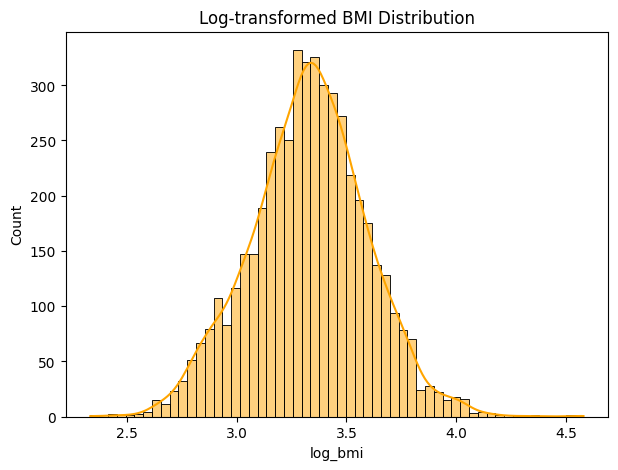

Original Skewness: 1.06
Log-transformed Skewness: 0.00


In [11]:
import numpy as np

# Log transformation to reduce skewness
df["log_bmi"] = np.log(df["bmi"])

# Visualizing the result of transformation
plt.figure(figsize=(7, 5))
sns.histplot(df["log_bmi"], kde=True, color="orange")
plt.title("Log-transformed BMI Distribution")
plt.show()

print(f"Original Skewness: {df['bmi'].skew():.2f}")
print(f"Log-transformed Skewness: {df['log_bmi'].skew():.2f}")

1.5. Выявить статистически аномальные значения (выбросы). Принять решение об их
исключении.

In [14]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


print(f"Lower bound for BMI: {lower_bound:.2f}")
print(f"Upper bound for BMI: {upper_bound:.2f}")

outliers = df[(df["bmi"] < lower_bound) | (df["bmi"] > upper_bound)]
df = df[(df["bmi"] >= lower_bound) & (df["bmi"] <= upper_bound)]

print(f"Dataset size after outlier removal: {len(df)}")
print(f"Trimmed Skewness: {df['bmi'].skew():.2f}")

Lower bound for BMI: 9.60
Upper bound for BMI: 46.40
Dataset size after outlier removal: 4786
Trimmed Skewness: 0.29


1.6. Корреляционный анализ - исследовать корреляционную связь между исходными
данными;

In [ ]:
r, p_val = stats.pearsonr(df["age"], df["bmi"])
print(f"Pearson Correlation Coefficient: {r:.4f}")
print(f"Pearson Correlation p-val: {p_val:.4f}")

print(f"Pearson Linear correlation: {p_val < 0.05}")

Pearson Correlation Coefficient: 0.3880
Pearson Correlation p-val: 0.0000
Pearson Linear correlation: True


1.7. С помощью модуля statsmodels.formula.api (as smf) получить результаты для линейной
регрессионной модели на основе обычного метода наименьших квадратов (Ordinary Least
Squares):

In [17]:
import statsmodels.formula.api as smf

# 1.7. Constructing the OLS regression model
# bmi (dependent variable Y) ~ age (independent variable X)
model = smf.ols(formula="bmi ~ age", data=df).fit()

# View the regression results table
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    bmi   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     847.6
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          1.05e-171
Time:                        22:45:22   Log-Likelihood:                -15561.
No. Observations:                4786   AIC:                         3.113e+04
Df Residuals:                    4784   BIC:                         3.114e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3086      0.193    120.983      0.0

1.8. На основе модулей sklearn.preprocessing (понадобится функция PolynomialFeatures) и
sklearn.linear_model (понадобится функция LinearRegression) построить полиномиальное
уравнение регрессии. Вид модели выбрать самостоятельно.

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# 1. Data Preparation
# Sklearn requires features (X) to be a 2D array, so we use .values and reshape if needed
X = df[["age"]].values
y = df["bmi"].values

# 2. Feature Engineering: Polynomial Transformation
# Create a transformer for a 2nd-degree polynomial (parabola)
# include_bias=False prevents adding a column of 1s (LinearRegression handles the intercept)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
# X_poly now contains two features: [age, age^2]

# 3. Model Training
# Initialize and fit the standard OLS Linear Regression on the transformed features
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# 4. Extracting Coefficients
# beta0 is the intercept, while beta1 and beta2 are the weights for Age and Age^2
beta0 = poly_model.intercept_
beta1, beta2 = poly_model.coef_

print(f"Equation: BMI = {beta0:.2f} + {beta1:.2f}*Age + {beta2:.4f}*Age^2")

# 5. Model Evaluation and Comparison
# Generate predictions for both the simple linear model and the polynomial model
y_pred_lin = model.predict(df["age"])  # Using the model from step 1.7
y_pred_poly = poly_model.predict(X_poly)

# Calculate and compare R-squared (Coefficient of Determination) values
# This helps decide if the added complexity of a polynomial is worth it
print(f"R-squared (Linear): {r2_score(y, y_pred_lin):.4f}")
print(f"R-squared (Polynomial): {r2_score(y, y_pred_poly):.4f}")

Equation: BMI = 17.45 + 0.52*Age + -0.0049*Age^2
R-squared (Linear): 0.1505
R-squared (Polynomial): 0.2844


1.9. Сравнить линейную и полиномиальную модель на основе квадрата отклонения
предсказанных результатов от экспериментальных данных.

In [30]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate Mean Squared Error (MSE) for both models
# Lower MSE indicates a better fit to the data
mse_lin = mean_squared_error(df["bmi"], y_pred_lin)
mse_poly = mean_squared_error(df["bmi"], y_pred_poly)

# Calculate R-squared (Coefficient of Determination)
# Tells us what percentage of BMI variance is explained by Age
r2_lin = r2_score(df["bmi"], y_pred_lin)
r2_poly = r2_score(df["bmi"], y_pred_poly)

# Print comparison results
print(f"Linear Model - MSE: {mse_lin:.4f}, R2: {r2_lin:.4f}")
print(f"Polynomial Model - MSE: {mse_poly:.4f}, R2: {r2_poly:.4f}")

Linear Model - MSE: 39.0447, R2: 0.1505
Polynomial Model - MSE: 32.8918, R2: 0.2844


1.10. Построить график уравнений линейной и полиномиальной регрессии совместно с
диаграммой рассеяния.

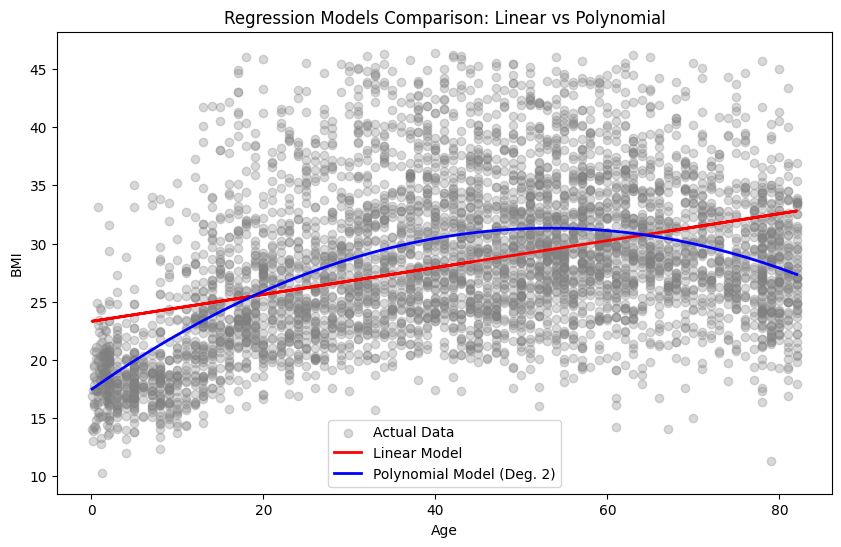

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with specific size
plt.figure(figsize=(10, 6))

# Plot the raw data as a scatter plot
# alpha=0.3 makes points semi-transparent to see density
plt.scatter(df["age"], df["bmi"], alpha=0.3, label="Actual Data", color="gray")

# Plot the Linear Regression model
# This represents the best-fit straight line
plt.plot(df["age"], y_pred_lin, color="red", label="Linear Model", linewidth=2)

# Plot the Polynomial Regression model
# Sorting is necessary to prevent the line from jumping back and forth between points
sort_idx = np.argsort(df["age"])
plt.plot(
    df["age"].iloc[sort_idx],
    y_pred_poly[sort_idx],
    color="blue",
    label="Polynomial Model (Deg. 2)",
    linewidth=2,
)

# Labeling the axes and adding a legend
plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend()

# Adding a descriptive title
plt.title("Regression Models Comparison: Linear vs Polynomial")

# Render the plot
plt.show()

2.1 Подготовить данные для анализа.

2.2. Сделать визуализацию данных.

C:\Users\Qweyke\AppData\Local\Temp\ipykernel_12916\4118760246.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stroke", y="age", data=df, palette="Set2")


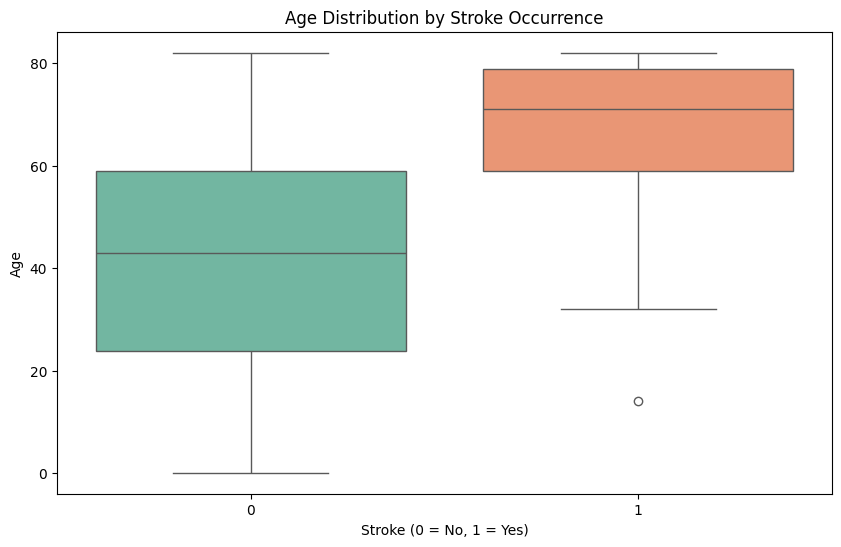

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Create a boxplot to compare age distribution for both stroke outcomes
sns.boxplot(x="stroke", y="age", data=df, palette="Set2")

# Set English labels and title
plt.title("Age Distribution by Stroke Occurrence")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

2.3. Провести разделение данных на обучающие и тестовые. Функция train_test_split из
модуля sklearn.model_selection.

In [36]:
from sklearn.model_selection import train_test_split

# 1. Define predictors (X) and target variable (y)
# We use 'age' to predict the 'stroke' outcome
X = df[["age"]]
y = df["stroke"]

# 2. Split the dataset into training and testing sets
# test_size=0.2 means 20% of data goes to testing, 80% to training
# random_state=42 ensures the split is reproducible (same results every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Verify the split sizes
print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# 4. Check class balance in the training set
# It's important to see how many stroke cases (1) are in the training data
print(f"Target distribution in training set:\n{y_train.value_counts()}")

Training set size: 3828 samples
Testing set size: 958 samples
Target distribution in training set:
stroke
0    3677
1     151
Name: count, dtype: int64


In [37]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the Logistic Regression model
# We use default settings, which are sufficient for this task
log_reg = LogisticRegression()

# 2. Fit the model using the training data
# The model finds the best weights (beta) to separate 'stroke' from 'no stroke'
log_reg.fit(X_train, y_train)

# 3. Extract the parameters
# intercept_ is beta0 (the bias term)
# coef_ is beta1 (the weight of the 'age' variable)
intercept = log_reg.intercept_[0]
coefficient = log_reg.coef_[0][0]

print(
    f"Logit Equation parameters: Intercept (beta0) = {intercept:.4f}, Slope (beta1) = {coefficient:.4f}"
)

# 4. Display the resulting probability formula
print(f"P(Stroke) = 1 / (1 + exp(-({intercept:.4f} + {coefficient:.4f} * Age)))")

Logit Equation parameters: Intercept (beta0) = -7.4398, Slope (beta1) = 0.0748
P(Stroke) = 1 / (1 + exp(-(-7.4398 + 0.0748 * Age)))


In [38]:
# 1. Predict categorical outcomes (0 for No Stroke, 1 for Stroke)
# The model uses a default threshold of 0.5
y_pred = log_reg.predict(X_test)

# 2. Predict probabilities for each class
# Output is an array where the second column [:, 1] is the probability of Stroke (1)
y_prob = log_reg.predict_proba(X_test)[:, 1]

# 3. Create a comparison dataframe to see first 10 results
comparison_df = X_test.copy()
comparison_df["Actual_Stroke"] = y_test
comparison_df["Predicted_Stroke"] = y_pred
comparison_df["Probability_of_Stroke"] = y_prob

print("First 10 predictions on the test set:")
print(comparison_df.head(10))

First 10 predictions on the test set:
       age  Actual_Stroke  Predicted_Stroke  Probability_of_Stroke
3120  22.0              0                 0               0.003036
4739  24.0              0                 0               0.003524
2491  50.0              0                 0               0.024131
840    9.0              0                 0               0.001150
4699  59.0              0                 0               0.046237
2905  65.0              0                 0               0.070579
4807  36.0              0                 0               0.008603
620   33.0              0                 0               0.006886
2968  59.0              0                 0               0.046237
40    78.0              1                 0               0.167223


In [ ]:
from sklearn.metrics import classification_report

y_pred_custom = (y_prob > 0.1).astype(int)
# This report gives you Precision, Recall and F1-score
# It's the gold standard for evaluating classification
print("\nClassification Report:")
print(
    classification_report(y_test, y_pred_custom, target_names=["No Stroke", "Stroke"])
)


Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.94      1.00      0.97       903
      Stroke       0.00      0.00      0.00        55

    accuracy                           0.94       958
   macro avg       0.47      0.50      0.49       958
weighted avg       0.89      0.94      0.91       958



c:\Users\Qweyke\CodeProjects\class-stat-methods-of-info-processing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Qweyke\CodeProjects\class-stat-methods-of-info-processing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Qweyke\CodeProjects\class-stat-methods-of-info-processing\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio